In [1]:
!pip install requests

In [2]:
!pip install langchain_groq
from langchain_groq import ChatGroq

In [3]:
!pip install langchain_google_genai

In [4]:
!pip install langchain langchain-core langchain-community pydantic duckduckgo-search langchain_experimental

In [5]:
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage

## Built-in Tool - DuckDuckGo Search

In [7]:
!pip install ddgs
from langchain_community.tools import DuckDuckGoSearchRun

In [8]:
search_tool = DuckDuckGoSearchRun()

results = search_tool.invoke('top news in india today')

print(results)

5 hours ago - He demanded resignations, an apology from PM Modi, withdrawal of cases and reforms in the education system. Canada's Indian-origin foreign minister Anita Anand visited Pakistan, marking the first visit by a Canadian foreign minister in nearly two decades, where she announced 47 million dollars in aid and unveiled new trade, investment and security initiatives as Ottawa seeks to deepen ties with Islamabad despite regional tensions. 4 hours ago - CJP protest in Delhi LIVE: Nadda meets doctors in Delhi's Ram Manohar Lohia hospital to enquire about the injured ... CJP's parliament march from Jantar Mantar: India's 'cockroach' protest continues a day after police crackdown 14 hours ago - National news and headlines from within or around India with live updates on major breaking events from The Hindu. 3 hours ago - India's equity benchmarks logged a third straight weekly gain on Thursday, their longest winning streak in seven months, as crude oil prices fell to pre-Iran-war lev

In [9]:
print(search_tool.name)
print(search_tool.description)
print(search_tool.args)

duckduckgo_search
A wrapper around DuckDuckGo Search. Useful for when you need to answer questions about current events. Input should be a search query.
{'query': {'description': 'search query to look up', 'title': 'Query', 'type': 'string'}}


## Built-in Tool - Shell Tool

In [10]:
from langchain_community.tools import ShellTool


In [11]:
shell_tool = ShellTool()

results = shell_tool.invoke('ls')

print(results)

Executing command:
 ls
sample_data



/usr/local/lib/python3.12/dist-packages/langchain_community/tools/shell/tool.py:33: UserWarning: The shell tool has no safeguards by default. Use at your own risk.
  warnings.warn(


## Custom Tools

In [12]:
from langchain_core.tools import tool

In [13]:
# Step 3 - add tool decorator

@tool
def multiply(a: int, b:int) -> int:
    """Multiply two numbers"""
    return a*b

In [14]:
result = multiply.invoke({"a":3, "b":5})

In [15]:
print(result)

15


In [16]:
print(multiply.name)
print(multiply.description)
print(multiply.args)

multiply
Multiply two numbers
{'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}


In [17]:
print(multiply.args_schema.model_json_schema())

{'description': 'Multiply two numbers', 'properties': {'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}, 'required': ['a', 'b'], 'title': 'multiply', 'type': 'object'}


## Method 2 - Using StructuredTool

In [18]:
from langchain_core.tools import StructuredTool
from pydantic import BaseModel, Field

In [19]:
class MultiplyInput(BaseModel):
    a: int = Field(required=True, description="The first number to add")
    b: int = Field(required=True, description="The second number to add")

/tmp/ipykernel_1198/3279971488.py:2: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'required'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  a: int = Field(required=True, description="The first number to add")
/tmp/ipykernel_1198/3279971488.py:3: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'required'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  b: int = Field(required=True, description="The second number to add")


In [20]:
def multiply_func(a: int, b: int) -> int:
    return a * b

In [21]:
multiply_tool = StructuredTool.from_function(
    func=multiply_func,
    name="multiply",
    description="Multiply two numbers",
    args_schema=MultiplyInput
)

In [22]:
result = multiply_tool.invoke({'a':3, 'b':3})

print(result)
print(multiply_tool.name)
print(multiply_tool.description)
print(multiply_tool.args)

9
multiply
Multiply two numbers
{'a': {'description': 'The first number to add', 'title': 'A', 'type': 'integer'}, 'b': {'description': 'The second number to add', 'title': 'B', 'type': 'integer'}}


## Method 3 - Using BaseTool Class

You should reach for BaseTool when you need strict validation of the LLM's inputs using Pydantic, when your tool requires complex initialization (like database connections), or when you need separate synchronous and asynchronous implementations.

In [23]:
from langchain.tools import BaseTool
from typing import Type

In [24]:
# arg schema using pydantic

class MultiplyInput(BaseModel):
    a: int = Field(required=True, description="The first number to add")
    b: int = Field(required=True, description="The second number to add")

/tmp/ipykernel_1198/908171234.py:4: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'required'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  a: int = Field(required=True, description="The first number to add")
/tmp/ipykernel_1198/908171234.py:5: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'required'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  b: int = Field(required=True, description="The second number to add")


In [25]:
class MultiplyTool(BaseTool):
    name: str = "multiply"
    description: str = "Multiply two numbers"

    args_schema: Type[BaseModel] = MultiplyInput

    def _run(self, a: int, b: int) -> int:
        return a * b

In [26]:
multiply_tool = MultiplyTool()

In [27]:
result = multiply_tool.invoke({'a':3, 'b':3})

print(result)
print(multiply_tool.name)
print(multiply_tool.description)

print(multiply_tool.args)

9
multiply
Multiply two numbers
{'a': {'description': 'The first number to add', 'title': 'A', 'type': 'integer'}, 'b': {'description': 'The second number to add', 'title': 'B', 'type': 'integer'}}


## Toolkit

Under the hood, a Toolkit is a Python class that implements a .get_tools() method. This method returns a standard list of BaseTool objects that you can immediately pass to an agent.

In [28]:
from langchain_core.tools import tool

# Custom tools
@tool
def add(a: int, b: int) -> int:
    """Add two numbers"""
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """Multiply two numbers"""
    return a * b


In [25]:
tools = [add, multiply]
for tool in tools:
  print(tool.name, "=>", tool.description)

add => Add two numbers
multiply => Multiply two numbers


In [29]:
class MathToolkit:
    def get_tools(self):
        return [add, multiply]


In [27]:
toolkit = MathToolkit()
tools = toolkit.get_tools()

for tool in tools:
    print(tool.name, "=>", tool.description)


### TOOL CALLING

In [49]:
from langchain_core.tools import tool

## When you decorate with @tool, you don’t manually instantiate StructuredTool. The decorator does that for you. Then you just collect those tool objects in a list and pass them to .bind_tools

In [50]:
#tool creation
@tool
def multiply(a: int, b: int) -> int:
    """Multiply two numbers"""
    return a * b
@tool
def add(a: int, b: int) -> int:
  """Add two numbers"""
  return a + b
@tool
def get_current_weather(location: str, unit: str) -> str:
    """Get the current weather in a given location"""

### With @tool: Python does that behind the scenes, and gives you back the object under the same function name.

### Here, multiply, get_current_weather and add are now StructuredTool instances.

In [51]:
print(multiply.invoke({"a" : 5, 'b' : 3}))

15


In [52]:
print(multiply.name)
print(multiply.description)
print(multiply.args)

multiply
Multiply two numbers
{'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}


In [81]:
from google.colab import userdata
Groq_api_key = userdata.get('GROQ_KEY_2')

In [42]:

llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.2,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    api_key=Groq_api_key,
    # other params...
)

In [43]:
llm.invoke('hii')

AIMessage(content='Hey there! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "hii". We need to respond. It\'s a greeting. Should be friendly. No special instructions. Just respond.'}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 73, 'total_tokens': 122, 'completion_time': 0.102206049, 'completion_tokens_details': {'reasoning_tokens': 28}, 'prompt_time': 0.003476285, 'prompt_tokens_details': None, 'queue_time': 0.319898178, 'total_time': 0.105682334}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_dd854ee2d7', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f8861-9374-7b70-8adb-b88d7a010731-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 73, 'output_tokens': 49, 'total_tokens': 122, 'output_token_details': {'reasoning': 28}})

In [44]:
tools = [multiply, add]

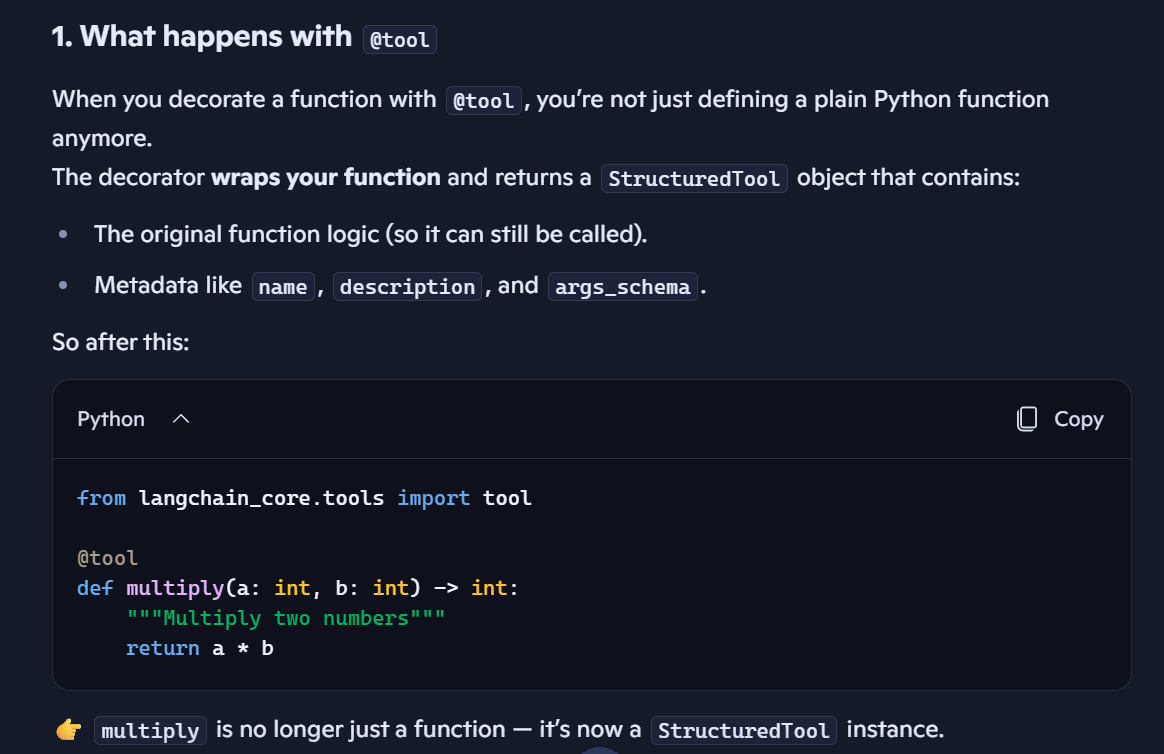

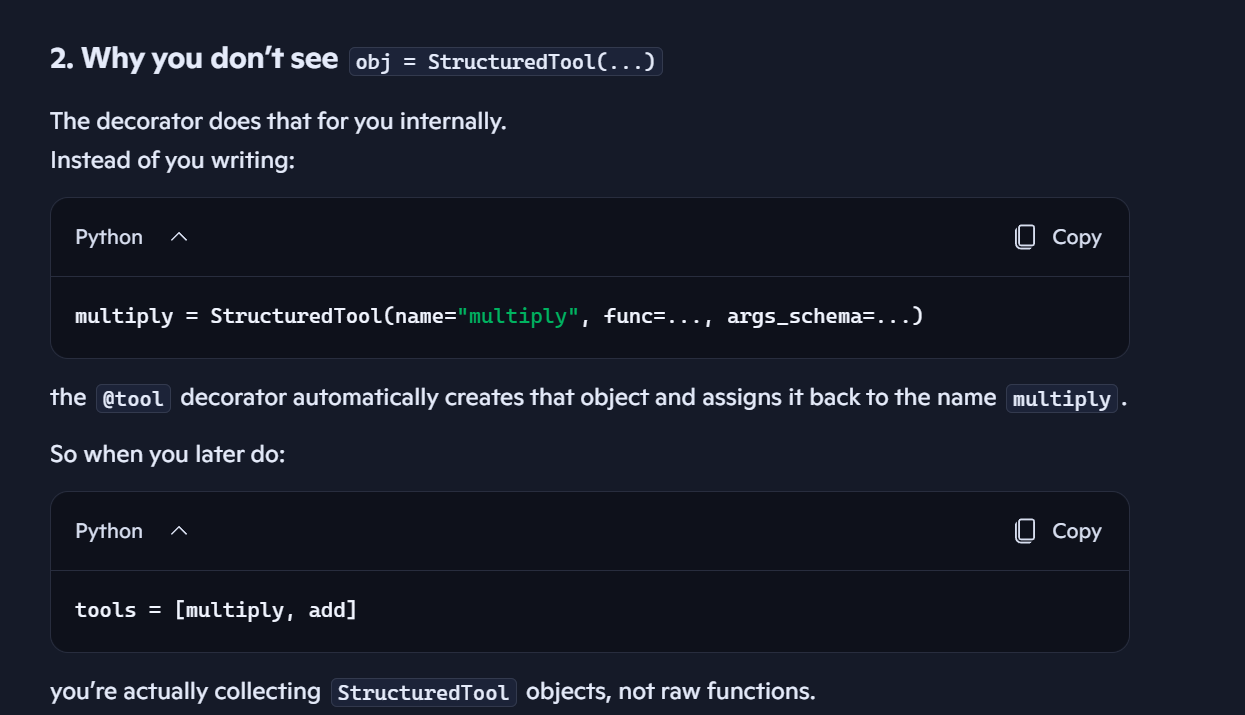

## tool binding

In [45]:
llm_with_tools = llm.bind_tools(tools)

In [46]:
llm_with_tools.invoke("Hii")

AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'We need to respond. The user says "Hii". Probably a greeting. We can respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 40, 'prompt_tokens': 144, 'total_tokens': 184, 'completion_time': 0.082551299, 'completion_tokens_details': {'reasoning_tokens': 22}, 'prompt_time': 0.00607131, 'prompt_tokens_details': None, 'queue_time': 0.283178736, 'total_time': 0.088622609}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_3af2d41834', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f8861-e345-7f73-bbb7-5ba21c677e08-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 144, 'output_tokens': 40, 'total_tokens': 184, 'output_token_details': {'reasoning': 22}})

In [54]:
query = HumanMessage(content = 'can you multiply 3 with 1000')

In [55]:
messages = [query]

In [56]:
messages

[HumanMessage(content='can you multiply 3 with 1000', additional_kwargs={}, response_metadata={})]

## Tool Calling

In [57]:
result = llm_with_tools.invoke(messages)
result

AIMessage(content='', additional_kwargs={'reasoning_content': 'User wants to multiply 3 with 1000. Use multiply function.', 'tool_calls': [{'id': 'fc_0e0fd3eb-6369-437f-b718-6f00052d92fd', 'function': {'arguments': '{"a":3,"b":1000}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 151, 'total_tokens': 201, 'completion_time': 0.104513388, 'completion_tokens_details': {'reasoning_tokens': 16}, 'prompt_time': 0.035730547, 'prompt_tokens_details': None, 'queue_time': 0.29027972, 'total_time': 0.140243935}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_df9620fe21', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f8863-98e1-71f2-9da2-c0a647d94e6b-0', tool_calls=[{'name': 'multiply', 'args': {'a': 3, 'b': 1000}, 'id': 'fc_0e0fd3eb-6369-437f-b718-6f00052d92fd', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_toke

In [58]:
result.tool_calls

[{'name': 'multiply',
  'args': {'a': 3, 'b': 1000},
  'id': 'fc_0e0fd3eb-6369-437f-b718-6f00052d92fd',
  'type': 'tool_call'}]

In [59]:
result.tool_calls[0]

{'name': 'multiply',
 'args': {'a': 3, 'b': 1000},
 'id': 'fc_0e0fd3eb-6369-437f-b718-6f00052d92fd',
 'type': 'tool_call'}

In [60]:
messages.append(result)

In [61]:
messages

[HumanMessage(content='can you multiply 3 with 1000', additional_kwargs={}, response_metadata={}),
 AIMessage(content='', additional_kwargs={'reasoning_content': 'User wants to multiply 3 with 1000. Use multiply function.', 'tool_calls': [{'id': 'fc_0e0fd3eb-6369-437f-b718-6f00052d92fd', 'function': {'arguments': '{"a":3,"b":1000}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 151, 'total_tokens': 201, 'completion_time': 0.104513388, 'completion_tokens_details': {'reasoning_tokens': 16}, 'prompt_time': 0.035730547, 'prompt_tokens_details': None, 'queue_time': 0.29027972, 'total_time': 0.140243935}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_df9620fe21', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f8863-98e1-71f2-9da2-c0a647d94e6b-0', tool_calls=[{'name': 'multiply', 'args': {'a': 3, 'b': 1000}, 'id': 'fc_0e0fd3eb-636

## tool execution

In [63]:
tool_result = multiply.invoke(result.tool_calls[0])
tool_result

ToolMessage(content='3000', name='multiply', tool_call_id='fc_0e0fd3eb-6369-437f-b718-6f00052d92fd')

In [64]:
messages.append(tool_result)

In [65]:
messages

[HumanMessage(content='can you multiply 3 with 1000', additional_kwargs={}, response_metadata={}),
 AIMessage(content='', additional_kwargs={'reasoning_content': 'User wants to multiply 3 with 1000. Use multiply function.', 'tool_calls': [{'id': 'fc_0e0fd3eb-6369-437f-b718-6f00052d92fd', 'function': {'arguments': '{"a":3,"b":1000}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 151, 'total_tokens': 201, 'completion_time': 0.104513388, 'completion_tokens_details': {'reasoning_tokens': 16}, 'prompt_time': 0.035730547, 'prompt_tokens_details': None, 'queue_time': 0.29027972, 'total_time': 0.140243935}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_df9620fe21', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f8863-98e1-71f2-9da2-c0a647d94e6b-0', tool_calls=[{'name': 'multiply', 'args': {'a': 3, 'b': 1000}, 'id': 'fc_0e0fd3eb-636

In [67]:
ans = llm_with_tools.invoke(messages)

In [68]:
ans.content

'The product of\u202f3\u202fand\u202f1000\u202fis\u202f**3000**.'

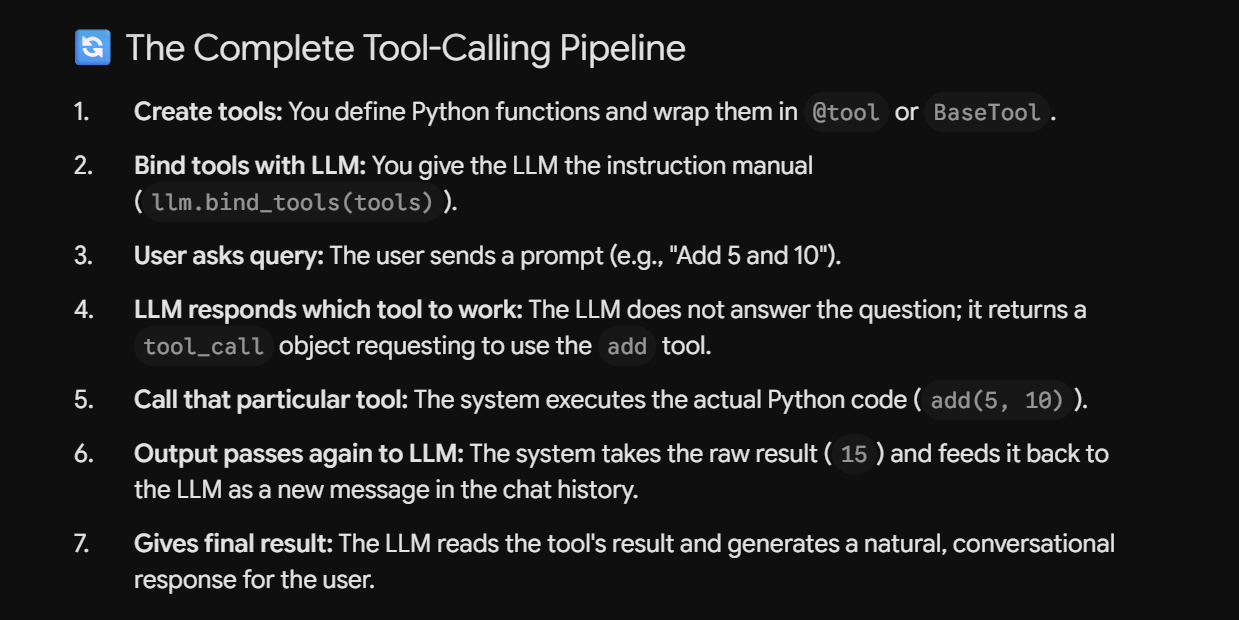

-Basically above pipeline --> create tools -> bind tools with llm -> user ask query to llm binded tools -> llm respond which tool to work -> call that particular tool -> output of that tool pass again to llm -> gives result

In [69]:
from langchain_core.tools import tool

@tool
def add(a: int, b: int) -> int:
    """Add two numbers"""
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """Multiply two numbers"""
    return a * b

# 1. Put your tools in a list
tools = [add, multiply]


# 3. Bind the tools to the LLM
llm_with_tools = llm.bind_tools(tools)

# 1. Ask a question that requires math
messages = [{"role": "user", "content": "What is 15 multiplied by 4?"}]
ai_response = llm_with_tools.invoke(messages)

# 2. The LLM responds with a request to use a tool, NOT the final answer.
print(ai_response.tool_calls)
# Output: [{'name': 'multiply', 'args': {'a': 15, 'b': 4}, 'id': 'call_abc123'}]

# 3. Create a dictionary to map the tool names to the actual Python functions
tool_map = {"add": add, "multiply": multiply}

# 4. Loop through the tool calls, find the right tool, and execute it
for tool_call in ai_response.tool_calls:
    selected_tool = tool_map[tool_call["name"].lower()]
    tool_args = tool_call["args"]

    # Execute the actual Python tool!
    result = selected_tool.invoke(tool_args)
    print(f"The tool calculated: {result}")
    # Output: The tool calculated: 60


[]


##Another Way of tool calling-> Agent Way

In [ ]:
# https://v6.exchangerate-api.com/v6/1a82283709e591423251fd74/pair/EUR/GBP

In [71]:
import requests

- InjectedToolArg  ->> "LLM, do not try to fill this argument." "I (the developer/runtime) will inject this value after running earlier tools."

In [ ]:
# tool create
from langchain_core.tools import InjectedToolArg
from typing import Annotated

@tool
def get_conversion_factor(base_currency: str, target_currency: str) -> float:
  """
  This function fetches the currency conversion factor between a given base currency and a target currency
  """
  url = f'https://v6.exchangerate-api.com/v6/1a82283709e591423251fd74/pair/{base_currency}/{target_currency}'

  response = requests.get(url)

  return response.json()

@tool
def convert(base_currency_value: int, conversion_rate: Annotated[float, InjectedToolArg("get_conversion_factor")]) -> float:
  """
  given a currency conversion rate this function calculates the target currency value from a given base currency value
  """

  return base_currency_value * conversion_rate

### conversion_rate will be injected automatically from the output of get_conversion_factor. But this only works if get_conversion_factor really returns a float (not a dict). Otherwise injection will fail.

In [ ]:
### it is just for understanding only it should not be executed


@tool
def get_conversion_factor(base_currency: str, target_currency: str) -> float:
    """
    Fetch the currency conversion factor between base and target currency
    """
    url = f'https://v6.exchangerate-api.com/v6/1a82283709e591423251fd74/pair/{base_currency}/{target_currency}'
    response = requests.get(url)
    data = response.json()
    return data["conversion_rate"]

@tool
def convert(base_currency_value: int, conversion_rate: Annotated[float, InjectedToolArg("get_conversion_factor")]) -> float:
    """
    Given a currency conversion rate, calculate the target currency value
    """
    return base_currency_value * conversion_rate

In [73]:
get_conversion_factor.invoke({'base_currency' : 'USD', 'target_currency' : 'INR'})

{'result': 'success',
 'documentation': 'https://www.exchangerate-api.com/docs',
 'terms_of_use': 'https://www.exchangerate-api.com/terms',
 'time_last_update_unix': 1784678401,
 'time_last_update_utc': 'Wed, 22 Jul 2026 00:00:01 +0000',
 'time_next_update_unix': 1784764801,
 'time_next_update_utc': 'Thu, 23 Jul 2026 00:00:01 +0000',
 'base_code': 'USD',
 'target_code': 'INR',
 'conversion_rate': 96.338}

In [74]:
convert.args

{'base_currency_value': {'title': 'Base Currency Value', 'type': 'integer'}}

In [75]:
convert.invoke({'base_currency_value': 10, 'conversion_rate' : 85.33})

853.3

In [76]:
tools = [get_conversion_factor, convert]

In [77]:
llm_with_tool = llm.bind_tools(tools)

In [78]:
messages = [HumanMessage('What is the conversion factor between INR and USD, and based on that can you convert 10 inr to usd')]

In [84]:
result = llm_with_tool.invoke(messages)
result

AIMessage(content='', additional_kwargs={'reasoning_content': 'We need conversion factor between INR and USD. Use get_conversion_factor with base_currency "INR", target_currency "USD". Then use convert with base_currency_value 10. Probably need to call function.', 'tool_calls': [{'id': 'fc_1a1ebe33-7d6b-47ff-af8b-363663f385b5', 'function': {'arguments': '{"base_currency":"INR","target_currency":"USD"}', 'name': 'get_conversion_factor'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 80, 'prompt_tokens': 196, 'total_tokens': 276, 'completion_time': 0.169990211, 'completion_tokens_details': {'reasoning_tokens': 42}, 'prompt_time': 0.008615937, 'prompt_tokens_details': None, 'queue_time': 0.280420019, 'total_time': 0.178606148}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_9241e9962b', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f88a6-cc3b-72e3-beac-776b5e03c240-0'

In [85]:
result.tool_calls

[{'name': 'get_conversion_factor',
  'args': {'base_currency': 'INR', 'target_currency': 'USD'},
  'id': 'fc_1a1ebe33-7d6b-47ff-af8b-363663f385b5',
  'type': 'tool_call'}]

In [88]:
msg1 = get_conversion_factor.invoke(result.tool_calls[0])
msg1

ToolMessage(content='{"result": "success", "documentation": "https://www.exchangerate-api.com/docs", "terms_of_use": "https://www.exchangerate-api.com/terms", "time_last_update_unix": 1784678401, "time_last_update_utc": "Wed, 22 Jul 2026 00:00:01 +0000", "time_next_update_unix": 1784764801, "time_next_update_utc": "Thu, 23 Jul 2026 00:00:01 +0000", "base_code": "INR", "target_code": "USD", "conversion_rate": 0.01038}', name='get_conversion_factor', tool_call_id='fc_1a1ebe33-7d6b-47ff-af8b-363663f385b5')

In [86]:
messages.append(result)

In [89]:
messages.append(msg1)

In [90]:
messages

[HumanMessage(content='What is the conversion factor between INR and USD, and based on that can you convert 10 inr to usd', additional_kwargs={}, response_metadata={}),
 AIMessage(content='', additional_kwargs={'reasoning_content': 'We need conversion factor between INR and USD. Use get_conversion_factor with base_currency "INR", target_currency "USD". Then use convert with base_currency_value 10. Probably need to call function.', 'tool_calls': [{'id': 'fc_1a1ebe33-7d6b-47ff-af8b-363663f385b5', 'function': {'arguments': '{"base_currency":"INR","target_currency":"USD"}', 'name': 'get_conversion_factor'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 80, 'prompt_tokens': 196, 'total_tokens': 276, 'completion_time': 0.169990211, 'completion_tokens_details': {'reasoning_tokens': 42}, 'prompt_time': 0.008615937, 'prompt_tokens_details': None, 'queue_time': 0.280420019, 'total_time': 0.178606148}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp

In [93]:
import json

In [96]:
conversion_factor = json.loads(msg1.content)['conversion_rate']
conversion_factor

0.01038

In [98]:
base_currency = json.loads(msg1.content)['base_code']
base_currency

'INR'

In [99]:
msg2 = convert.invoke({'base_currency_value': 10, 'conversion_rate' : conversion_factor})
msg2

0.1038

In [101]:
messages.append(ToolMessage(content=msg2, name='convert', tool_call_id="dbsdbjas"))

In [102]:
messages

[HumanMessage(content='What is the conversion factor between INR and USD, and based on that can you convert 10 inr to usd', additional_kwargs={}, response_metadata={}),
 AIMessage(content='', additional_kwargs={'reasoning_content': 'We need conversion factor between INR and USD. Use get_conversion_factor with base_currency "INR", target_currency "USD". Then use convert with base_currency_value 10. Probably need to call function.', 'tool_calls': [{'id': 'fc_1a1ebe33-7d6b-47ff-af8b-363663f385b5', 'function': {'arguments': '{"base_currency":"INR","target_currency":"USD"}', 'name': 'get_conversion_factor'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 80, 'prompt_tokens': 196, 'total_tokens': 276, 'completion_time': 0.169990211, 'completion_tokens_details': {'reasoning_tokens': 42}, 'prompt_time': 0.008615937, 'prompt_tokens_details': None, 'queue_time': 0.280420019, 'total_time': 0.178606148}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp

In [103]:
llm_with_tools.invoke(messages).content

'The current conversion factor is **≈\u202f0.01038\u202fUSD per\u202f1\u202fINR**.  \n\nSo, converting 10\u202fINR:\n\n\\[\n10 \\text{ INR} \\times 0.01038 \\frac{\\text{USD}}{\\text{INR}} \\approx 0.1038 \\text{ USD}\n\\]\n\n**≈\u202f$0.10\u202fUSD**.'

### Agentic Way of Tool Calling

In [7]:
from langchain_google_genai import ChatGoogleGenerativeAI

In [8]:
from google.colab import userdata
GEMINI_API_KEY = userdata.get('Gemini_API_KEY')

In [9]:


llm_gemini = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    google_api_key=GEMINI_API_KEY
)

In [10]:
from langchain_core.tools import tool